# ASL Träning
***Marcus Johansson 2026***

DEMO: https://kunskapskontroll.biscuitlab.com/

Vi ska försöka använda oss av ett kaggle dataset för träning initialt.
<s>https://www.kaggle.com/datasets/grassknoted/asl-alphabet visade vara fel och på tyska, fick rulla tillbaka och hitta nytt</s>

Bytte till https://www.kaggle.com/datasets/debashishsau/aslamerican-sign-language-aplhabet-dataset som har ett stor set samt ett test-set med.

Utöver vanliga biblioteken så laddar vi också in mediapipe samt opencv python.
*Vi använder hand_landmarker.task från google, för att få ut landmarks från bilderna.*

Jag har läst lite på poster på nätet, samt manualer. 
Jag kommer dela upp arbetet i flera delar.

Första är att konvertera bilderna av händerna och tecknen, till ren data i csv format.
Detta löser vi med ett separat script och med hjälpa av PipeMedia och OpenCV.

Detta ska vi sen avända för att träna modellen.
Vi kan sen börja utföra tester, vilke modell som passar bäst.



In [18]:

##landmarkl_extrahering.ipynb
"""Går igenom alla mappar och laddar in 500 bilder från varje mapp, plockar ut landmarks och lägger dessa 21 st till en csv fil"""

'Går igenom alla mappar och laddar in 500 bilder från varje mapp, plockar ut landmarks och lägger dessa 21 st till en csv fil'

In [19]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import os
import csv
import pandas as pd
import numpy as np


# -- Configen
DATA_FIL = 'asl_landmarks.csv'


Vad innehåller den csv? Vi vet ju vad vi skapade, men vi vill se vad som finns

In [20]:
data_frame = pd.read_csv(DATA_FIL)

print('Storlek:', data_frame.shape)
print('Bokstäver:', data_frame['label'].unique())
data_frame.head()

#Räkna hur många per klass
print('Antal per klass:')
print('-----------------')
print(data_frame['label'].value_counts().sort_index())

Storlek: (28922, 43)
Bokstäver: <ArrowStringArray>
[    'A',     'B',     'C',     'D',     'E',     'F',     'G',     'H',
     'I',     'J',     'K',     'L',     'M',     'N',     'O',     'P',
     'Q',     'R',     'S',     'T',     'U',     'V',     'W',     'X',
     'Y',     'Z',   'del', 'space']
Length: 28, dtype: str
Antal per klass:
-----------------
label
A        1262
B        1520
C        1200
D        1088
E        1458
F        1302
G        1068
H        1582
I        1472
J        1562
K        1156
L        1162
M        1016
N         774
O        1338
P        1274
Q        1306
R         783
S         734
T         731
U         790
V         562
W         545
X         683
Y         732
Z         779
del       573
space     470
Name: count, dtype: int64


In [21]:
#skapa data
X = data_frame.drop('label', axis=1).values #vi tar bort label från data och lägger bara värdena i X
Y = data_frame['label'].values #sparar label i y

print('X shape:', X.shape)
print('Y shape:', Y.shape)

X shape: (28922, 42)
Y shape: (28922,)


Här gick vi lite vilse först.. vi måste 

In [22]:
#from pandas.api.types import CategoricalDtype
##pd.Categorical..började jag med men det var inte helt rätt. labeleoncode kan decoda tillbaka vilket vi vill
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(Y)

print('Klasser:', le.classes_)
print('Y encoded shape:', y_encoded.shape)
print('Y encoded:', y_encoded)


Klasser: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z' 'del' 'space']
Y encoded shape: (28922,)
Y encoded: [ 0  0  0 ... 27 27 27]


In [23]:
from sklearn.model_selection import train_test_split
#dela upp i träning och test, 20% test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f'Träning: {X_train.shape[0]} exempel')
print(f'Test:    {X_test.shape[0]} exempel')


Träning: 23137 exempel
Test:    5785 exempel


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

X_train shape: (23137, 42)
X_test shape: (5785, 42)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print('Random Forest tränad!')

In [ ]:

from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=10, random_state=42)
svm.fit(X_train, y_train)
print('SVM tränad!')


SVM tränad!


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print('KNN tränad!')


KNN tränad!


In [ ]:
from sklearn.metrics import accuracy_score

modeller = {'Random Forest': rf, 'SVM': svm, 'KNN': knn}

for namn, modell in modeller.items():
    y_pred = modell.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f'{namn}: {acc:.3f}')


Random Forest: 0.970
SVM: 0.984
KNN: 0.922


#### Vi kör en GridSearchCV för att försöka hitta bästa resultat/modell 

Vi kör detta efter vi tränat modellerna för att det går snabbare

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

param_grids = {
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20]}
    ),
    'SVM': (
        SVC(probability=True, random_state=42),
        {'C': [1, 10, 100], 'gamma': ['scale', 'auto'], 'kernel': ['rbf']}
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'n_neighbors': [3, 5, 10], 'weights': ['uniform', 'distance']}
    )
}

for namn, (modell, params) in param_grids.items():
    grid = GridSearchCV(modell, params, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    print(f'{namn}: {grid.best_score_:.3f} — {grid.best_params_}')

Random Forest: 0.967 — {'max_depth': None, 'n_estimators': 200}
SVM: 0.987 — {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
KNN: 0.954 — {'n_neighbors': 3, 'weights': 'distance'}


#### SVM fungerade bäst, vi tränar om modellen med de nya pametrarna



In [ ]:
from sklearn.metrics import classification_report

basta_modell = SVC(kernel='rbf', C=100, gamma='scale', probability=True, random_state=42)
basta_modell.fit(X_train, y_train)

y_pred = basta_modell.predict(X_test)

print(f'Accuracy på testdata: {accuracy_score(y_test, y_pred):.3f}')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy på testdata: 0.992
              precision    recall  f1-score   support

           A       0.98      1.00      0.99       252
           B       0.99      1.00      1.00       304
           C       0.99      1.00      0.99       240
           D       1.00      0.99      0.99       218
           E       1.00      0.99      0.99       292
           F       1.00      0.99      1.00       260
           G       1.00      1.00      1.00       214
           H       0.99      0.99      0.99       317
           I       1.00      1.00      1.00       294
           J       1.00      1.00      1.00       312
           K       0.99      1.00      1.00       231
           L       0.99      1.00      1.00       232
           M       0.99      1.00      0.99       203
           N       0.99      0.97      0.98       155
           O       1.00      1.00      1.00       268
           P       0.98      1.00      0.99       255
           Q       1.00      0.98      0.99       261

#### Vi kör en confusion matrix och försöker hitta missar

Accuracy: 0.992

              precision    recall  f1-score   support

           A       0.98      1.00      0.99       252
           B       0.99      1.00      1.00       304
           C       0.99      1.00      0.99       240
           D       1.00      0.99      0.99       218
           E       1.00      0.99      0.99       292
           F       1.00      0.99      1.00       260
           G       1.00      1.00      1.00       214
           H       0.99      0.99      0.99       317
           I       1.00      1.00      1.00       294
           J       1.00      1.00      1.00       312
           K       0.99      1.00      1.00       231
           L       0.99      1.00      1.00       232
           M       0.99      1.00      0.99       203
           N       0.99      0.97      0.98       155
           O       1.00      1.00      1.00       268
           P       0.98      1.00      0.99       255
           Q       1.00      0.98      0.99       261
          

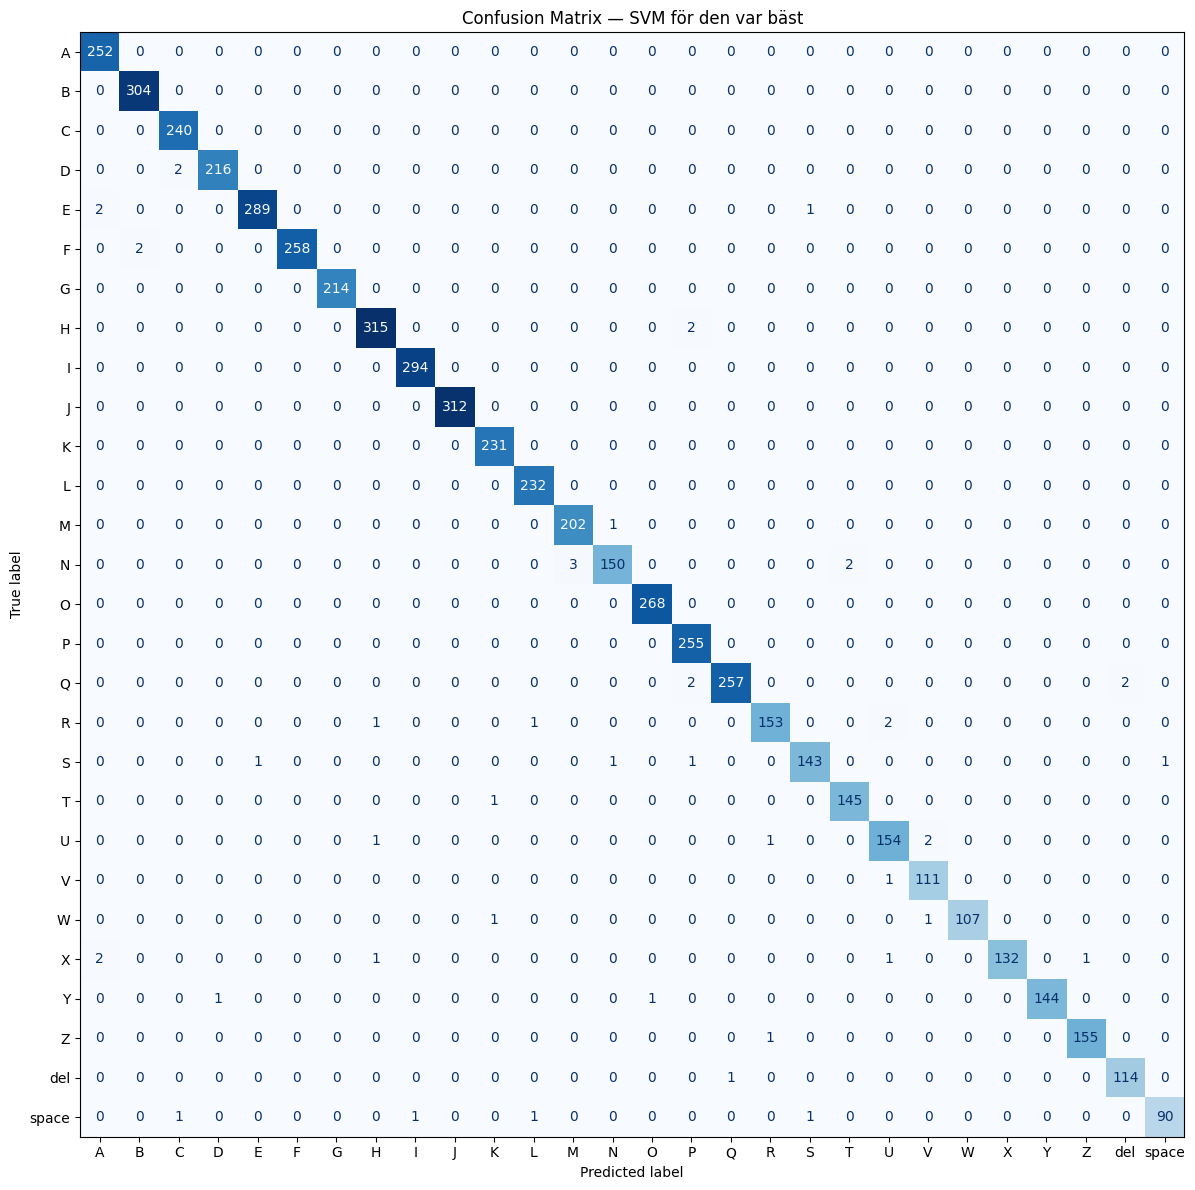

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

y_pred_basta = basta_modell.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred_basta):.3f}')
print()
print(classification_report(y_test, y_pred_basta, target_names=le.classes_))


cm = confusion_matrix(y_test, y_pred_basta)
fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — SVM för den var bäst')
plt.tight_layout()
plt.show()

## Försöker hitta outliers



A: 12 outliers av 1262
B: 16 outliers av 1520
C: 12 outliers av 1200
D: 10 outliers av 1088
E: 14 outliers av 1458
F: 14 outliers av 1302
G: 8 outliers av 1068
H: 16 outliers av 1582
I: 14 outliers av 1472
J: 16 outliers av 1562
K: 12 outliers av 1156
L: 12 outliers av 1162
M: 10 outliers av 1016
N: 8 outliers av 774
O: 14 outliers av 1338
P: 12 outliers av 1274
Q: 14 outliers av 1306
R: 8 outliers av 783
S: 8 outliers av 734
T: 8 outliers av 731
U: 8 outliers av 790
V: 6 outliers av 562
W: 6 outliers av 545
X: 7 outliers av 683
Y: 8 outliers av 732
Z: 8 outliers av 779
del: 6 outliers av 573
space: 5 outliers av 470


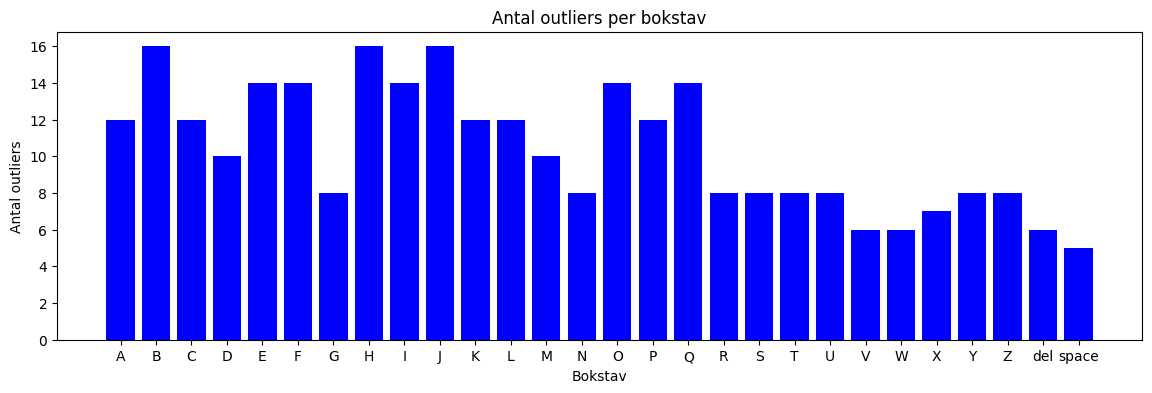

In [ ]:
# Hitta outliers per klass med Isolation Forest
from sklearn.ensemble import IsolationForest

outliers_per_class = {}

for bokstav in le.classes_:
    # Filtrera ut bara den bokstavens rader
    mask = data_frame['label'] == bokstav
    X_klass = data_frame[mask].drop('label', axis=1).values
    
    # Kör Isolation Forest
    iso = IsolationForest(contamination=0.01, random_state=42)
    pred = iso.fit_predict(X_klass)
    
    antal_outliers = (pred == -1).sum()
    outliers_per_class[bokstav] = antal_outliers
    print(f'{bokstav}: {antal_outliers} outliers av {len(X_klass)}')


plt.figure(figsize=(14, 4))
plt.bar(outliers_per_class.keys(), outliers_per_class.values(), color='blue')
plt.title('Antal outliers per bokstav')
plt.xlabel('Bokstav')
plt.ylabel('Antal outliers')
plt.show()


In [ ]:
"""PCA verkar skjut vilt så vi sk*ter i den
from sklearn.decomposition import PCA

import numpy as np

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(10, 8))

# Plotta alla andra bokstäver grå
mask_övrigt = (data_frame['label'] != 'M') & (data_frame['label'] != 'N') & (data_frame['label'] != 'L')
plt.scatter(X_2d[mask_övrigt, 0], X_2d[mask_övrigt, 1], 
            c='lightgray', alpha=0.3, s=10, label='Övriga')

# Plotta M och N i tydliga färger
mask_m = data_frame['label'] == 'M'
mask_n = data_frame['label'] == 'N'
mask_b = data_frame['label'] == 'L'
plt.scatter(X_2d[mask_b, 0], X_2d[mask_b, 1], 
            c='green', alpha=0.6, s=20, label='L')
plt.scatter(X_2d[mask_m, 0], X_2d[mask_m, 1], 
            c='red', alpha=0.6, s=20, label='M')
plt.scatter(X_2d[mask_n, 0], X_2d[mask_n, 1], 
            c='blue', alpha=0.6, s=20, label='N')


plt.legend()
plt.title('PCA — M och N mot övriga')
plt.show()
"""

"PCA verkar skjut vilt så vi sk*ter i den\nfrom sklearn.decomposition import PCA\n\nimport numpy as np\n\npca = PCA(n_components=2)\nX_2d = pca.fit_transform(X)\n\nplt.figure(figsize=(10, 8))\n\n# Plotta alla andra bokstäver grå\nmask_övrigt = (data_frame['label'] != 'M') & (data_frame['label'] != 'N') & (data_frame['label'] != 'L')\nplt.scatter(X_2d[mask_övrigt, 0], X_2d[mask_övrigt, 1], \n            c='lightgray', alpha=0.3, s=10, label='Övriga')\n\n# Plotta M och N i tydliga färger\nmask_m = data_frame['label'] == 'M'\nmask_n = data_frame['label'] == 'N'\nmask_b = data_frame['label'] == 'L'\nplt.scatter(X_2d[mask_b, 0], X_2d[mask_b, 1], \n            c='green', alpha=0.6, s=20, label='L')\nplt.scatter(X_2d[mask_m, 0], X_2d[mask_m, 1], \n            c='red', alpha=0.6, s=20, label='M')\nplt.scatter(X_2d[mask_n, 0], X_2d[mask_n, 1], \n            c='blue', alpha=0.6, s=20, label='N')\n\n\nplt.legend()\nplt.title('PCA — M och N mot övriga')\nplt.show()\n"

## Slutsatser innan spara
Några sticker ut, M och N mest. brusiga koordinater? De är väldigt lika, och kan lätt förväxlas, men de ligger och också väldigt nära andra om man ser till CM.

Ser man dock på själva handhållningen, så är det ett fingersskillnad på m och n bokstaven. Handen pekar ligger också framför armen vid det tecknet, vilket nog gör det svårare, bra ljus krävs för att få det korrekt. Det uppstår bias av datasetet?.
Vi utökade handset med bättre motor för koordinaterna

 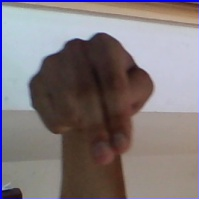 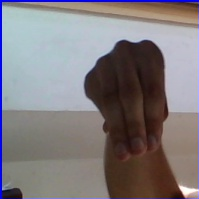

In [ ]:
import joblib

##joblib.dump(svm, 'new_asl_modell.pkl')
joblib.dump(scaler, 'new_asl_scaler.pkl')
joblib.dump(le, 'new_asl_label_encoder.pkl')

joblib.dump(basta_modell, 'new_asl_modell.pkl')
print(classification_report(y_test, y_pred, target_names=le.classes_))


              precision    recall  f1-score   support

           A       0.98      1.00      0.99       252
           B       0.99      1.00      1.00       304
           C       0.99      1.00      0.99       240
           D       1.00      0.99      0.99       218
           E       1.00      0.99      0.99       292
           F       1.00      0.99      1.00       260
           G       1.00      1.00      1.00       214
           H       0.99      0.99      0.99       317
           I       1.00      1.00      1.00       294
           J       1.00      1.00      1.00       312
           K       0.99      1.00      1.00       231
           L       0.99      1.00      1.00       232
           M       0.99      1.00      0.99       203
           N       0.99      0.97      0.98       155
           O       1.00      1.00      1.00       268
           P       0.98      1.00      0.99       255
           Q       1.00      0.98      0.99       261
           R       0.99    

## Slutsats

Det blev för mycket att köra bildinläsningen direkt och processa, så det ligger i en egen notebook landmark_extrahering.ipynb.

Här bytte jag strategi efter tag då datan vi fick med koordinater, var bristfällig, och väldigt svag på framförallt M & N.
Genom att verifiera hur många av bilderna den faktiskt kunde hitta koordinater så kunde jag vid behov trigga om inläsningen med fler bilder för att få större och säkrare dataset.

Läste runt (och bollade med en annan utvecklare), och bestämde mig för att validera mot köra klassificeringarna genom 3 olika modeller för utvärdering.
RandomForrest, SVM, KNN, där SVM gav bäst resultat.

En grid_search lades till för att testa igenom SVM när modellern var klar.

jag undersökte datan med Isolation Forest för att hitta outliers, men analysen visade en jämn fördelning vilket tyder på att datasetet är relativt rent. Större förbättringar kom istället från att balansera träningsdatan för M och N, samt GridSearch


